# 2110573 PATTERN RECOGNITION

## **Homework 03:** GMM

- **Author:** Worralop Srichainont
- **Year:** 2025 (Semester 2)

# **Task**: Hello Soft Clustering (GMM)

- **Problem**: T1 - T4

# Dependencies

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Problem `T1`

Using 3 mixtures, initialize your Gaussian with means (3,3), (2,2), and (-3,-3), and standard Covariance, I, the identity matrix. Use equal mix- ture weights as the initial weights. Repeat three iterations of EM. Write down $w_{n,j}$ , $m_j$ , $\vec{μ_j}$, $\Sigma_j$ for each EM iteration. (You may do the calculations by hand or write code to do so)

<img src="https://drive.google.com/uc?id=1IW9XNrx4jNKRnP0UwyIbIDlo-6smgg10">

In [16]:
class GMM:
    def __init__(self, mixture_weight, mean_params, cov_params):
        """
        Initialize GMM.
        """
        # Copy construction values.
        self.mixture_weight = mixture_weight
        self.mean_params = mean_params
        self.cov_params = cov_params

        # Initiailize iteration.
        self.n_iter = 0

    def estimation_step(self, data):
        """
        Perform estimation step. Then, return w_{n,j} in from the equation 1
        """
        N = data.shape[0]
        K = len(self.mixture_weight)
        w = np.zeros((N, K))

        for idx in range(K):
            pdf = multivariate_normal.pdf(
                data, mean=self.mean_params[idx], cov=self.cov_params[idx]
            )
            w[:, idx] = self.mixture_weight[idx] * pdf

        denom = np.sum(w, axis=1, keepdims=True)
        denom[denom == 0] = 1e-10
        w /= denom

        return w

    def maximization_step(self, data, w):
        """
        Perform maximization step. (Update parameters in this GMM model.)
        """
        N = data.shape[0]
        K = len(self.mixture_weight)
        N_cols = np.sum(w, axis=0)

        for idx in range(K):
            self.mixture_weight[idx] = N_cols[idx] / N

            weighted_sum = np.sum(w[:, idx].reshape(-1, 1) * data, axis=0)
            self.mean_params[idx] = weighted_sum / N_cols[idx]

            diff = data - self.mean_params[idx]
            numerator_cov = np.dot(w[:, idx] * diff.T, diff)
            new_cov = numerator_cov / N_cols[idx]
            self.cov_params[idx] = new_cov * np.eye(2)

    def get_log_likelihood(self, data):
        """
        Compute log likelihood.
        """
        K = len(self.mixture_weight)
        N = data.shape[0]
        weighted_pdfs = np.zeros((N, K))

        for idx in range(K):
            pdf = multivariate_normal.pdf(
                data, mean=self.mean_params[idx], cov=self.cov_params[idx]
            )
            weighted_pdfs[:, idx] = pdf * self.mixture_weight[idx]
            sum_weighted_pdfs = np.sum(weighted_pdfs, axis=1)
            log_prob = np.sum(np.log(sum_weighted_pdfs + 1e-10))

        return log_prob

    def print_iteration(self):
        print("m :\n", self.mixture_weight)
        print("mu :\n", self.mean_params)
        print("covariance matrix :\n", self.cov_params)
        print("-------------------------------------------------------------")

    def perform_em_iterations(self, data, num_iterations, display=True):
        """
        Perform estimation & maximization steps with num_iterations.
        Then, return list of log_likelihood from those iterations.
        """
        log_prob_list = []

        # Display initialization.
        if display:
            print("Initialization")
            self.print_iteration()

        for n_iter in range(num_iterations):
            # Update parameters
            w = self.estimation_step(data)
            self.maximization_step(data, w)

            # Calculate log prob.
            log_prob = self.get_log_likelihood(data)
            log_prob_list.append(log_prob)

            # Display each iteration.
            if display:
                print(f"Iteration: {n_iter}")
                self.print_iteration()

        return log_prob_list

In [17]:
num_iterations = 3
num_mixture = 3
mixture_weight = [1] * num_mixture  # m
mean_params = np.array([[3, 3], [2, 2], [-3, -3]], dtype=float)
cov_params = np.array([np.eye(2)] * num_mixture)

X, Y = np.array([1, 3, 2, 8, 6, 7, -3, -2, -7]), np.array(
    [2, 3, 2, 8, 6, 7, -3, -4, -7]
)
data = np.vstack([X, Y]).T

gmm = GMM(mixture_weight, mean_params, cov_params)
log_prob_list = gmm.perform_em_iterations(data, num_iterations)

Initialization
m :
 [1, 1, 1]
mu :
 [[ 3.  3.]
 [ 2.  2.]
 [-3. -3.]]
covariance matrix :
 [[[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]]
-------------------------------------------------------------
Iteration: 0
m :
 [np.float64(0.45757241940119386), np.float64(0.20909424706571345), np.float64(0.33333333353309275)]
mu :
 [[ 5.78992692  5.81887265]
 [ 1.67718211  2.14523106]
 [-4.         -4.66666666]]
covariance matrix :
 [[[4.53619412 0.        ]
  [0.         4.28700611]]

 [[0.51645579 0.        ]
  [0.         0.13152618]]

 [[4.66666668 0.        ]
  [0.         2.88888891]]]
-------------------------------------------------------------
Iteration: 1
m :
 [np.float64(0.4071161831594476), np.float64(0.2595496084607245), np.float64(0.3333342083798279)]
mu :
 [[ 6.27176215  6.27262711]
 [ 1.72091544  2.14764812]
 [-3.99998589 -4.6666488 ]]
covariance matrix :
 [[[2.94672736 0.        ]
  [0.         2.93847196]]

 [[0.49649261 0.        ]
  [0.         0.12584815]]

## Result

**Initialization**
- Mixing Coefficients: `[1.0000, 1.0000, 1.0000]`
- Mean :
```
[[ 3.0000  3.0000]
 [ 2.0000  2.0000]
 [-3.0000 -3.0000]]
```
- Covariance Matrix:
```
[[[1.0000 0.0000]
  [0.0000 1.0000]]

 [[1.0000 0.0000]
  [0.0000 1.0000]]

 [[1.0000 0.0000]
  [0.0000 1.0000]]]
```

**Iteration 0**
- Mixing Coefficients: `[0.4576, 0.2091, 0.3333]`
- Mean :
```
[[ 5.7899  5.8188]
 [ 1.6772  2.1452]
 [-4.0000 -4.6667]]
```
- Covariance Matrix:
```
[[[4.5362 0.0000]
  [0.0000 4.2870]]

 [[0.5165 0.0000]
  [0.0000 0.1315]]

 [[4.6667 0.0000]
  [0.0000 2.8889]]]
```

**Iteration 1**
- Mixing Coefficients: `[0.4071, 0.2595, 0.3333]`
- Mean :
```
[[ 6.2718  6.2726]
 [ 1.7209  2.1476]
 [-4.0000 -4.6667]]
```
- Covariance Matrix:
```
[[[2.9467 0.0000]
  [0.0000 2.9385]]

 [[0.4965 0.0000]
  [0.0000 0.1258]]

 [[4.6667 0.0000]
  [0.0000 2.8889]]]
```

**Iteration 2**
- Mixing Coefficients: `[0.3607, 0.3060, 0.3333]`
- Mean :
```
[[ 6.6963  6.6963]
 [ 1.9107  2.2738]
 [-4.0000 -4.6667]]
```
- Covariance Matrix:
```
[[[1.7396 0.0000]
  [0.0000 1.7393]]

 [[0.6290 0.0000]
  [0.0000 0.1988]]

 [[4.6667 0.0000]
  [0.0000 2.8889]]]
```

# Problem `T2`

Plot the log likelihood of the model given the data after each EM step. In other words, plot $\log \prod_n p( \vec{x_n} |φ, \vec{μ} , Σ)$. Does it goes up every iteration just as we learned in class?

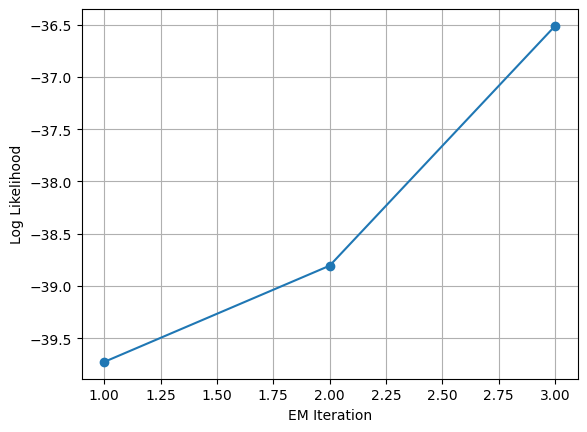

In [18]:
X_RANGE = range(1, num_iterations + 1)

plt.figure()
plt.plot(X_RANGE, log_prob_list, marker="o")

plt.xlabel("EM Iteration")
plt.ylabel("Log Likelihood")
plt.grid(True)

plt.show()

**ANSWER**: As we can see, the value increases for every iterations.

# Problem `T3`

Using 2 mixtures, initialize your Gaussian with means (3,3) and (-3,-3), and standard Covariance, I, the identity matrix. Use equal mixture weights as the initial weights. Repeat three iterations of EM. Write down $w_{n,j}$ , $m_j$ , $\vec{μ_j}$, $\Sigma_j$ for each EM iteration.

In [19]:
num_mixture = 2
mixture_weight = [1] * num_mixture

mean_params = np.array([[3, 3], [-3, -3]], dtype=float)
cov_params = np.array([np.eye(2)] * num_mixture)

gmm2 = GMM(mixture_weight, mean_params, cov_params)
log_prob_list2 = gmm2.perform_em_iterations(data, num_iterations=3)

Initialization
m :
 [1, 1]
mu :
 [[ 3.  3.]
 [-3. -3.]]
covariance matrix :
 [[[1. 0.]
  [0. 1.]]

 [[1. 0.]
  [0. 1.]]]
-------------------------------------------------------------
Iteration: 0
m :
 [np.float64(0.6666666649702521), np.float64(0.3333333350297478)]
mu :
 [[ 4.50000001  4.66666667]
 [-3.99999997 -4.66666663]]
covariance matrix :
 [[[6.91666665 0.        ]
  [0.         5.88888889]]

 [[4.66666677 0.        ]
  [0.         2.8888891 ]]]
-------------------------------------------------------------
Iteration: 1
m :
 [np.float64(0.6666943621060054), np.float64(0.33330563789399464)]
mu :
 [[ 4.49961311  4.66620178]
 [-3.99993241 -4.66651231]]
covariance matrix :
 [[[6.91944755 0.        ]
  [0.         5.89275124]]

 [[4.66806942 0.        ]
  [0.         2.89103318]]]
-------------------------------------------------------------
Iteration: 2
m :
 [np.float64(0.6666945259520648), np.float64(0.3333054740479351)]
mu :
 [[ 4.49961084  4.66619903]
 [-3.99993206 -4.66651141]]
co

## Result

**Initialization**
- Mixing Coefficients: `[1.0000, 1.0000]`
- Mean :
```
[[ 3.0000   3.0000]
 [-3.0000  -3.0000]]
```
- Covariance Matrix:
```
[[[1.0000 0.0000]
  [0.0000 1.0000]]

 [[0.5165 0.0000]
  [0.0000 0.1315]]]
```

**Iteration 0**
- Mixing Coefficients: `[0.6667, 0.3333]`
- Mean :
```
[[ 4.5000   4.6667]
 [-4.0000  -4.6667]]
```
- Covariance Matrix:
```
[[[6.9167 0.0000]
  [0.0000 5.8889]]

 [[4.6667 0.0000]
  [0.0000 2.8889]]]
```

**Iteration 1**
- Mixing Coefficients: `[0.6667, 0.3333]`
- Mean :
```
[[ 4.4996   4.6662]
 [-4.0000  -4.6665]]
```
- Covariance Matrix:
```
[[[6.9195 0.0000]
  [0.0000 5.8928]]

 [[4.6681 0.0000]
  [0.0000 2.8910]]]
```

**Iteration 2**
- Mixing Coefficients: `[0.6667, 0.3333]`
- Mean :
```
[[ 4.4996   4.6662]
 [-4.0000  -4.6665]]
```
- Covariance Matrix:
```
[[[6.9195 0.0000]
  [0.0000 5.8928]]

 [[4.6681 0.0000]
  [0.0000 2.8910]]]
```

# Problem `T4`

Plot the log likelihood of the model given the data after each EM step. Compare the log likelihood between using two mixtures and three mixtures. Which one has the better likelihood?

## Plot `log_likelihood` From `T3`

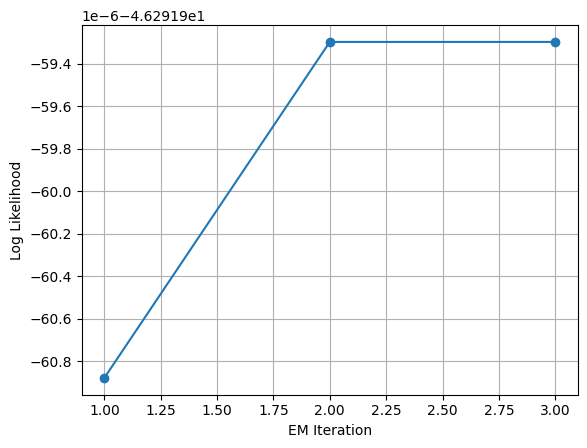

In [20]:
X_RANGE = range(1, len(log_prob_list2) + 1)

plt.figure()
plt.plot(X_RANGE, log_prob_list2, marker="o")

plt.xlabel("EM Iteration")
plt.ylabel("Log Likelihood")

plt.grid(True)
plt.show()

## Plot `log_likelihood` From `T1` and `T3`

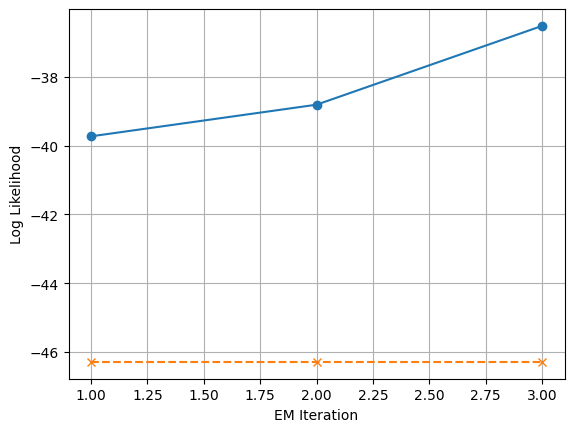

In [21]:
X_RANGE_T1 = range(1, len(log_prob_list) + 1)
X_RANGE_T3 = range(1, len(log_prob_list2) + 1)

plt.figure()
plt.plot(X_RANGE_T1, log_prob_list, marker="o")
plt.plot(X_RANGE_T3, log_prob_list2, marker="x", linestyle="--")

plt.xlabel("EM Iteration")
plt.ylabel("Log Likelihood")

plt.grid(True)
plt.show()

Display log likelihood of `T1` and `T3`

In [22]:
t1_log_likelihood = log_prob_list[-1]
t3_log_likelihood = log_prob_list2[-1]

print(f"T1: 3 Mixtures Log Likelihood: {t1_log_likelihood:.4f}")
print(f"T3: 2 Mixtures Log Likelihood: {t3_log_likelihood:.4f}")

T1: 3 Mixtures Log Likelihood: -36.5130
T3: 2 Mixtures Log Likelihood: -46.2920


**ANSWER**: The model with 3 mixtures has better likelihood